In [1]:
import sys 

sys.path.append("../..")

In [2]:
import numpy as np 
from tqdm import tqdm 
import torch
from torch import nn
from torch.nn import functional as F
from xaikd import models, datasets, bases

from pathlib import Path

from xaikd.utils import metrics


from matplotlib import pyplot as plt

In [3]:
model = models.get_model("cifar100-resnet18-p1")

In [4]:
class SubResnet(nn.Module):
    def __init__(self, model):
        super().__init__()
        
        self.model = model 
        
    def forward(self, x, early_stop=False):
        # do something 
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)
        
        x = self.model.layer1(x)
        x = self.model.layer2(x)
        x = self.model.layer3(x)
        
        if not early_stop:
            logits = self.model.layer4(x)
            logits = self.model.avgpool(logits)
            logits = torch.flatten(logits, 1)
            logits = self.model.fc(logits)
        else:
            logits = None
        return x, logits

In [5]:
@torch.no_grad()
def ano():
    def fh(module, inp, output):
        setattr(module, "__output", output)
    
    
    subresnet = SubResnet(model)
    
    try :
        
        module = model.layer3[-1] 
        hook = module.register_forward_hook(fh)
        
        x = torch.randn((10, 3, 32, 32))
        
        expected_logits = model(x)
        
        expected_act = getattr(module, "__output")
        
        actual_act, actual_logits = subresnet(x)
        
        np.testing.assert_allclose(actual_act, expected_act)
        np.testing.assert_allclose(actual_logits, expected_logits)

    finally:
        hook.remove()
        
    print("sanity check passed!")
ano()

sanity check passed!


In [6]:
subresnet = SubResnet(model)

In [7]:
np.random.seed(1)

num_training_samples = 500

ds = datasets.construct("cifar100-people", num_training_samples=num_training_samples)

train_loader = ds.loader(train_split=True, shuffle=True)
val_loader = ds.loader(train_split=False, shuffle=False)

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


# Setup Param

In [8]:
# basis_name = "pca--centered"
# basis_name = "prca-abs--centered"

K = 100


pca_basis = bases.get_basis("pca--centered")
pca_basis.load(
    artifact_dir=Path(
        f"../../artifacts/2023-06-s8/local/accuracy-basis/cifar100-people--n{num_training_samples}/logit-mod-oneclass/cifar100-resnet18-p1/layer3"
    )
)
                            
prca_basis = bases.get_basis("prca-abs--centered")
prca_basis.load(
    artifact_dir=Path(
        f"../../artifacts/2023-06-s8/local/accuracy-basis/cifar100-people--n{num_training_samples}/logit-mod-oneclass/cifar100-resnet18-p1/layer3"
    )
)

pcaprca_basis = bases.get_basis("pcaprca-abs--centered")
pcaprca_basis.load(
    artifact_dir=Path(
        f"../../artifacts/2023-06-s8/local/accuracy-basis/cifar100-people--n{num_training_samples}/logit-mod-oneclass/cifar100-resnet18-p1/layer3"
    )
)


# eigvals = basis.artifact["eigvals"]

# def whiten_projector(x):
    
#     x = projector(x)
    
#     shape = x.shape
     
#     x = x.flatten(start_dim=1) @ np.diag(eigvals[:K] ** (-0.5))
    
#     return x.reshape(shape)

In [23]:
for i in range(10):
    
    u_pca = pca_basis.artifact["eigvecs"][:, i]
    u_prca = prca_basis.artifact["eigvecs"][:, i]
    u_pcaprca = pcaprca_basis.artifact["eigvecs"][:, i]

    print(f"i={i}")
    print("> pca  @ prca", u_prca.dot(u_pca))
    print("> pca  @ pcaprca", u_pca.dot(u_pcaprca))
    print("> prca @ pcaprca", u_prca.dot(u_pcaprca))

i=0
> pca  @ prca tensor(-0.8707)
> pca  @ pcaprca tensor(-0.8710)
> prca @ pcaprca tensor(1.0000)
i=1
> pca  @ prca tensor(0.8453)
> pca  @ pcaprca tensor(0.8447)
> prca @ pcaprca tensor(0.9999)
i=2
> pca  @ prca tensor(-0.8721)
> pca  @ pcaprca tensor(-0.8676)
> prca @ pcaprca tensor(0.9992)
i=3
> pca  @ prca tensor(-0.2861)
> pca  @ pcaprca tensor(-0.3793)
> prca @ pcaprca tensor(-0.7136)
i=4
> pca  @ prca tensor(-0.0557)
> pca  @ pcaprca tensor(0.0532)
> prca @ pcaprca tensor(0.6883)
i=5
> pca  @ prca tensor(0.1547)
> pca  @ pcaprca tensor(-0.0157)
> prca @ pcaprca tensor(-0.9078)
i=6
> pca  @ prca tensor(-0.4840)
> pca  @ pcaprca tensor(0.5909)
> prca @ pcaprca tensor(-0.8298)
i=7
> pca  @ prca tensor(0.4090)
> pca  @ pcaprca tensor(0.2960)
> prca @ pcaprca tensor(0.8473)
i=8
> pca  @ prca tensor(-0.3733)
> pca  @ pcaprca tensor(-0.3991)
> prca @ pcaprca tensor(0.8101)
i=9
> pca  @ prca tensor(-0.1555)
> pca  @ pcaprca tensor(0.3577)
> prca @ pcaprca tensor(-0.7518)


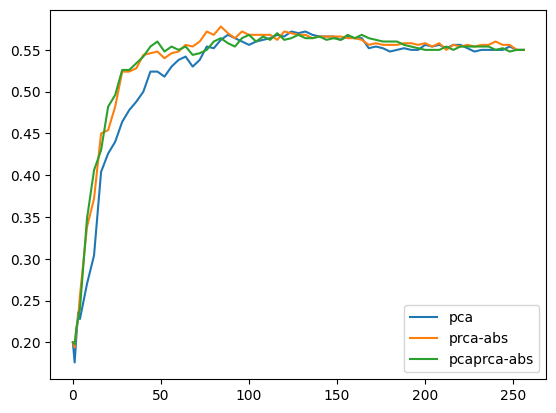

In [31]:
import json
def stats():
    
    for basis_name in ["pca", "prca-abs", "pcaprca-abs"]:
        
        with open(
            f"../../artifacts/2023-06-s8/local/accuracy-basis/cifar100-people--n{num_training_samples}/logit-mod-oneclass/cifar100-resnet18-p1/layer3/{basis_name}--centered/stats.json", "r") as fh:
            stats = json.load(fh)
        plt.plot(stats["arr_ks"], stats["arr_acc"], label=basis_name)
    plt.legend()
stats()

In [16]:
basis_name = "prca-abs--centered"

if basis_name == "pca--centered":
    basis = pca_basis
elif basis_name == "prca-abs--centered":
    basis = prca_basis
elif basis_name == "pcaprca-abs--centered":
    basis = pcaprca_basis
else:
    raise

projector = basis.construct_projection_on_rank_k(k=K, device="cpu")
decoder = basis.contruct_rank_d_decoder(k=K, device="cpu")

eigvals = basis.artifact["eigvals"]

def whiten_projector(x):
    return x

#     x = projector(x)
    
#     shape = x.shape
     
#     x = x.flatten(start_dim=1) @ np.diag(eigvals[:K] ** (-0.5))
    
#     return x.reshape(shape)

In [17]:
# layer4_basis = bases.get_basis(basis_name)
# layer4_basis.load(
#     artifact_dir=Path(
#         f"../../artifacts/2023-06-s8/local/accuracy-basis/cifar100-people--n{num_training_samples}/logit-mod-oneclass/cifar100-resnet18-p1/layer4"
#     )
# )


# K_layer4 = 6

# layer4_projector = layer4_basis.construct_projection_on_rank_k(k=K_layer4, device="cpu")
# layer4_decoder = layer4_basis.contruct_rank_d_decoder(k=K_layer4, device="cpu")

# Training SVR

In [18]:
from torchvision import transforms

In [19]:
@torch.no_grad()
def collect_feat_and_output(loader):
    
    arr_x = []
    
    arr_y = []
    
    shape = (1, 1)
    
#     pool = nn.AvgPool2d((shape))
    crop = nn.AdaptiveAvgPool2d(shape)
    
    
    for _ in range(1):
        for i, (x, _) in tqdm(enumerate(loader)):

            act, logits = subresnet(x)
            
            act = crop(act)
            act = whiten_projector(act)
#             print(act.shape)
#             cropped = act
            
# #             print("cropped", act.shape,)

# #             raise
#             flatten_cropped = cropped.flatten(start_dim=1)

#             projected_act = projector(cropped)

#             output = model.layer4(cropped)

#             projected_output = layer4_projector(output)

            arr_x.append(act.flatten(start_dim=1))

            arr_y.append(logits[:, ds.selected_classes])

    arr_x = np.vstack(arr_x)
    arr_y = np.vstack(arr_y)
    
    return arr_x, arr_y, shape
    
X, y, shape = collect_feat_and_output(train_loader)    

40it [00:33,  1.20it/s]


In [28]:
X.shape, y.shape

((2500, 100), (2500, 5))

In [29]:
from sklearn import svm
from sklearn.multioutput import MultiOutputRegressor

def fit_svm(X, y):
    regr = svm.SVR()

    regr = MultiOutputRegressor(regr)
    regr.fit(X, y)
    
    yh = regr.predict(X)
    
    err = ((yh - y)**2).mean(axis=0)
    
    print(f"err={err}")
    
    return regr

approxer = fit_svm(X, y)

err=[ 8.04335013  9.34999271 11.29529688  6.90800573  7.40215509]


In [36]:
def ano():
    
    ns = len(approxer.estimators_)
    for i in range(ns):
        print(f"support {i}:", approxer.estimators_[i].n_support_)
ano()

support 0: [2418]
support 1: [2434]
support 2: [2416]
support 3: [2388]
support 4: [2416]


In [31]:
from torch.nn import functional as F 



class SVCConvLayer(nn.Module):
    
    def __init__(self, approxers, X_training):
        super().__init__()
        ntraining, din = X_training.shape
        dout = len(approxer.estimators_)
        
        A = np.zeros((dout, ntraining))
        intercepts = np.zeros((dout, ))
        
        for i in range(dout):
            _est = approxer.estimators_[i]
            A[i, _est.support_] = _est.dual_coef_ 
            intercepts[i] = _est._intercept_
        
        self.A = torch.from_numpy(A).float()
        self.intercepts = torch.from_numpy(intercepts).float().reshape((1, dout, 1, 1))
        
        self.gamma = 1 / (din * X_training.var())
        
        X = torch.from_numpy(X_training).float()
        
        self.W = X.reshape((ntraining, -1, *shape))
        
        self.b = torch.linalg.norm(X, dim=1) ** 2
        self.b = self.b.reshape((1, ntraining, 1, 1))
        

    
    def forward(self, x):
        
        d = x.shape[1]
        
        norm_squared = F.conv2d(
            x ** 2,
            torch.ones(1, d, *shape),
            stride=2
        )
        
        
        out = F.conv2d(x, self.W, stride=2) 
        
        out = (2*out - norm_squared - self.b) * self.gamma
        out = torch.exp(out)
        
        out = torch.einsum(
            "ijkl,tj->itkl",
            out,
            self.A
        )

        out = out + self.intercepts


        return out
    
    
svc_module = SVCConvLayer(approxer, X)

@torch.no_grad()
def sanity_check():

    X, y = next(iter(val_loader))
    
    act, _ = subresnet(X)
    
    projected_act = projector(act)

    # subsampling
    projected_act = projected_act[:, :, :1, :1]
    
    
    expected = approxer.predict(projected_act.flatten(start_dim=1))
        
    actual = svc_module(projected_act).flatten(start_dim=1).numpy()
    
        
    np.testing.assert_allclose(
        actual,
        expected,
        atol=1e-3
    )
    
    print("sanity check passed!")
    
    
sanity_check()

sanity check passed!


In [32]:
# center_crop = transforms.CenterCrop((2, 2))
center_crop = nn.AdaptiveAvgPool2d(shape)

In [33]:
class ApproxResnet(nn.Module):
    def __init__(self, model):
        super().__init__()
        
        self.model = model 
    
    @torch.no_grad()
    def forward(self, x):
        # do something 
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)
        
        x = self.model.layer1(x)
        x = self.model.layer2(x)
        x = self.model.layer3(x)
#         print("layer4.shape", self.model.layer4(x).shape)
#         x = projector(x)
                
        
    
#         projected_act = projector(x)
        x = svc_module(whiten_projector(center_crop(x)))
    
        logits = torch.zeros((x.shape[0], 100))
        
        logits[:, ds.selected_classes] = x.flatten(start_dim=1)
# #         approx_out = svc_module(x)
# #         approx_out = layer4_projector(self.model.layer4(x))
#         x = layer4_decoder(approx_out)
#         x[:, :, [0, 3], :] = 0
#         x[:, :, :, [0, 3]] = 0
        
        
#         x = self.model.avgpool(x)
#         x = torch.flatten(x, 1)
#         logits = self.model.fc(x)

        return logits
    
approx_resnet = ApproxResnet(model)

approx_resnet(torch.randn((10, 3, 32, 32)));

In [34]:
acc = metrics.accuracy_with_subclasses(approx_resnet, val_loader, ds.selected_classes, ds.transform_target, device="cpu")

print(f"- {basis_name}(N={num_training_samples}, K={K}): acc={acc:.4f}")

- prca-abs--centered(N=500, K=100): acc=0.4920


In [35]:
metrics.accuracy_with_subclasses(model, val_loader, ds.selected_classes, ds.transform_target, device="cpu")

0.550000011920929

basisline=0.55

- prca-abs--centered(N=50, K=10): acc=0.3760
- pca--centered(N=50, K=10): acc=0.3080

- pca--centered(N=50, K=25): acc=0.3680
- prca-abs--centered(N=50, K=25): acc=0.3780

- pca--centered(N=50, K=100): acc=0.4040
- prca-abs--centered(N=50, K=100): acc=0.4100

----

- pca--centered(N=500, K=10): acc=0.3760
- prca-abs--centered(N=500, K=10): acc=0.4060
- pca--centered(N=500, K=25): acc=0.4520
- prca-abs--centered(N=500, K=25): acc=0.4960
- pca--centered(N=500, K=100): acc=0.4940
- prca-abs--centered(N=500, K=100): acc=0.5000

- prca-abs--centered(N=500, K=256): acc=0.5180

- pca--centered(N=500, K=256): acc=0.5160





